# Clinical ML Case Study: Coronary Artery Disease Prediction

## 1. Abstract / Executive Summary

This notebook develops and validates a clinical machine learning workflow for predicting the presence of coronary artery disease (CAD) using the public UCI Heart Disease dataset. The main development cohort is the Cleveland dataset with 303 patients and 14 original variables. The target is binarized as no CAD (`target = 0`) versus CAD present (`target > 0`).

The final benchmark model is a logistic regression pipeline using all 13 Cleveland predictors after complete-case filtering. The notebook preserves the original decision to use complete-case analysis because only 6 Cleveland records contain missing values. The complete-case development dataset contains 297 patients.

The benchmark model achieved a held-out test ROC-AUC of 0.929. A threshold of 0.30 was emphasized because it prioritized clinical sensitivity: sensitivity 0.929, specificity 0.812, accuracy 0.867, 2 missed CAD cases, and 6 false alarms on the 60-patient test set. Internal validation and model comparisons did not show a meaningful improvement from random forest, gradient boosting, or spline logistic regression over the logistic benchmark. A reduced external-validation model using shared predictors was evaluated on Hungarian, Switzerland, and Long Beach VA cohorts, showing partial transportability and weaker performance in Long Beach VA.

**Why this step matters:** Reviewers need the objective, data, model, validation design, and headline results before reading implementation details.

**Decision made:** Keep the reproducible notebook's scientific decisions and results unchanged while presenting them as an academic clinical ML case study.

**Clinical interpretation:** The model is best understood as a decision-support demonstration, not a deployable diagnostic tool.

**Limitation:** The data are historical, small, and retrospective; external transportability is incomplete.


# Project Decision Tree

This decision tree summarizes the analytical path followed in this notebook, from dataset loading to external validation and clinical interpretation.

```text
FULL PROJECT DECISION TREE

Start

1. Dataset loaded
   -> Cleveland Heart Disease dataset
      -> 303 patients, 14 original columns

2. Target definition
   -> Original target: 0, 1, 2, 3, 4
      -> Converted to binary:
         - 0 = No CAD
         - 1 = CAD present

3. Missing values
   -> Missing in ca and thal
      -> Complete-case baseline chosen
         -> df_complete = 297 patients

4. Continuous EDA
   -> Variables: age, trestbps, chol, thalach, oldpeak
      -> Non-normal distributions
         -> Used median/IQR + Mann-Whitney U
            -> Strongest signals:
               - thalach
               - oldpeak
               - age

5. Categorical EDA
   -> Variables: sex, cp, fbs, restecg, exang, slope, ca, thal
      -> Used chi-square/Fisher logic + Cramer's V
         -> Strongest categorical signals:
            - thal
            - cp
            - ca
            - exang
            - slope

6. Benchmark modeling decision
   -> Use all 13 predictors first
      -> Preprocessing:
         - continuous -> StandardScaler
         - categorical -> OneHotEncoder

7. Main model
   -> Regularized logistic regression
      -> Best C = 1
         -> Test performance:
            - ROC-AUC = 0.929
            - Accuracy = 0.800 at threshold 0.50

8. Threshold analysis
   -> Threshold 0.30 chosen for screening logic
      -> Results:
         - Accuracy = 0.867
         - Sensitivity = 0.929
         - Specificity = 0.812
         - Missed CAD = 2
         - False alarms = 6

9. Model validation
   -> Calibration checked
      -> Brier score = 0.111
         -> Probabilities reasonably trustworthy

   -> Repeated CV checked
      -> Logistic regression stable
         - ROC-AUC approx 0.897
         - Accuracy approx 0.829

   -> Bootstrap CI checked
      -> Model strong but uncertainty remains because test set = 60 patients

10. Alternative models
    -> Random Forest
       -> Did not beat logistic regression
    -> Gradient Boosting
       -> Did not beat logistic regression
    -> Spline logistic regression
       -> No meaningful nonlinear improvement

11. Clinical realism issue
    -> ca is strong but clinically close to angiographic information
       -> Built Model B without ca
          -> Performance dropped slightly
             -> Conclusion:
                - with ca = best benchmark model
                - without ca = more clinically realistic model

12. External validation idea
    -> Other UCI hospitals checked:
       - Hungarian
       - Switzerland
       - Long Beach VA

13. Full 13-variable external validation
    -> Not possible
       -> Too much missingness in ca, thal, slope, etc.

14. Reduced external-validation model
    -> Shared variables: age, sex, cp, restecg, chol
       -> Train on Cleveland
       -> Test on external hospitals

15. External validation results
    -> Hungarian:
       - ROC-AUC = 0.830 -> reasonable transfer
    -> Switzerland:
       - ROC-AUC = 0.757 -> moderate transfer
    -> Long Beach VA:
       - ROC-AUC = 0.672 -> weak transfer

FINAL CONCLUSION

-> Logistic regression with ca is the best benchmark model.
   Logistic regression without ca is the more clinically realistic sensitivity model.
   External validation shows performance is heterogeneous across hospitals.
   Therefore, the model is promising but should be treated as clinical decision support,
   not a replacement for clinicians or diagnostic procedures.
```


## 2. Research Question

Can routinely available clinical variables from the UCI Cleveland Heart Disease dataset be used to estimate the probability that a patient has coronary artery disease?

The practical modeling question is binary:

- `0`: No CAD
- `1`: CAD present

The notebook focuses on prediction rather than causal inference. Association tests are used for screening and clinical understanding, while the primary predictive model is logistic regression.

**Why this step matters:** A clinical prediction notebook must distinguish prediction from explanation and avoid causal overclaiming.

**Decision made:** Model the probability of CAD presence using a binary target and preserve the original emphasis on sensitivity at a lower decision threshold.

**Clinical interpretation:** A high predicted probability may support further clinical evaluation, but it cannot confirm CAD by itself.

**Limitation:** The research question is constrained by the variables available in the public UCI dataset.


## 3. Data Source and Study Design

The analysis uses the processed UCI Heart Disease datasets. The Cleveland cohort is used for model development, internal validation, and held-out test evaluation. The Hungarian, Switzerland, and Long Beach VA cohorts are used later for external validation with a reduced predictor set.

This is a retrospective secondary analysis of public tabular clinical data. The notebook does not collect new patient data and does not make prospective clinical claims.

**Why this step matters:** Clinical ML reporting should identify the development cohort, validation cohorts, and retrospective nature of the study.

**Decision made:** Use Cleveland as the primary development dataset and reserve other UCI cohorts for external validation.

**Clinical interpretation:** External cohorts represent different case mixes and missingness patterns, so performance outside Cleveland is expected to vary.

**Limitation:** The public datasets do not provide all modern clinical context needed for deployment-level validation.


## 4. Data Dictionary

| Variable | Type in analysis | Meaning |
|---|---|---|
| `age` | Continuous | Patient age in years |
| `sex` | Categorical | Patient sex coded in the source dataset |
| `cp` | Categorical | Chest pain type |
| `trestbps` | Continuous | Resting blood pressure |
| `chol` | Continuous | Serum cholesterol |
| `fbs` | Categorical | Fasting blood sugar indicator |
| `restecg` | Categorical | Resting electrocardiographic result |
| `thalach` | Continuous | Maximum heart rate achieved |
| `exang` | Categorical | Exercise-induced angina indicator |
| `oldpeak` | Continuous | ST depression induced by exercise relative to rest |
| `slope` | Categorical | Slope of peak exercise ST segment |
| `ca` | Categorical | Number of major vessels colored by fluoroscopy |
| `thal` | Categorical | Thalassemia-related test result code |
| `target` | Outcome | Original UCI disease status; `0` means no CAD and nonzero values indicate CAD presence |

**Why this step matters:** Reviewers need to know which variables are measurements, which are clinical categories, and which are source codes.

**Decision made:** Preserve the original variable handling: continuous variables are scaled and categorical variables are one-hot encoded.

**Clinical interpretation:** Some predictors, especially `ca` and `thal`, may reflect more advanced diagnostic information than basic screening variables.

**Limitation:** The notebook uses source coding as provided by UCI; it does not relabel all category levels into full clinical text.


In [ ]:
# Reproducibility configuration
# Centralized constants used throughout the notebook.

RANDOM_STATE = 42

DATASET_URLS = {
    "cleveland": "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "hungarian": "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "switzerland": "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "long_beach_va": "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data",
}

CLEVELAND_URL = DATASET_URLS["cleveland"]

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

CONTINUOUS_VARS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_VARS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
THRESHOLDS = [0.30, 0.40, 0.50, 0.60]

SHARED_VARS = ["age", "sex", "cp", "restecg", "chol"]
SHARED_CONTINUOUS = ["age", "chol"]
SHARED_CATEGORICAL = ["sex", "cp", "restecg"]

# This warning is expected when a CV fold lacks a category that appears in validation.
# OneHotEncoder(handle_unknown="ignore") handles it deterministically by encoding as all zeros.
KNOWN_ONEHOT_WARNING = (
    "Found unknown categories in columns .* during transform. "
    "These unknown categories will be encoded as all zeros"
)


In [16]:
import pandas as pd

url = CLEVELAND_URL
columns = COLUMNS

df = pd.read_csv(url, names=columns, na_values="?")

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [18]:
df.shape

(303, 14)

## 5. Outcome Definition

The original UCI target has multiple values. This analysis converts it into a binary clinical prediction target:

- `target_binary = 0`: no CAD (`target = 0`)
- `target_binary = 1`: CAD present (`target > 0`)

This binarization matches the notebook's clinical goal: predicting whether CAD is present, not predicting severity grade.

**Why this step matters:** A model's interpretation depends on the outcome definition. Binary CAD presence is different from multiclass disease severity.

**Decision made:** Preserve the original binary target decision used in the reproducible notebook.

**Clinical interpretation:** The model estimates probability of CAD presence across any nonzero disease category.

**Limitation:** Severity information in the original target is collapsed into a binary label.


## 6. Missing Data Assessment

Before modeling, the notebook inspects incomplete records and evaluates whether missingness is rare enough for complete-case analysis. In the Cleveland dataset, missingness is limited to `ca` and `thal`, affecting 6 records total.

The analysis checks missing rows, visualizes missingness against CAD status, and compares missingness by target status. The complete-case analysis retains 297 of 303 Cleveland patients.

**Why this step matters:** Missing data can bias clinical prediction models and can make external validation infeasible if the same variables are not available across cohorts.

**Decision made:** Use complete-case analysis for the Cleveland development model because missingness is rare in the primary cohort.

**Clinical interpretation:** The primary model is trained on patients with complete values for all 13 predictors.

**Limitation:** Complete-case analysis is transparent but may still introduce bias if missingness is not random.


In [19]:
df[df.isna().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [20]:
# Build an explicit working dataframe for clean top-to-bottom execution.
df_work = df.copy()
df_work["target_binary"] = (df_work["target"] > 0).astype(int)

df_work[["target", "target_binary"]].head()


,target,target_binary
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


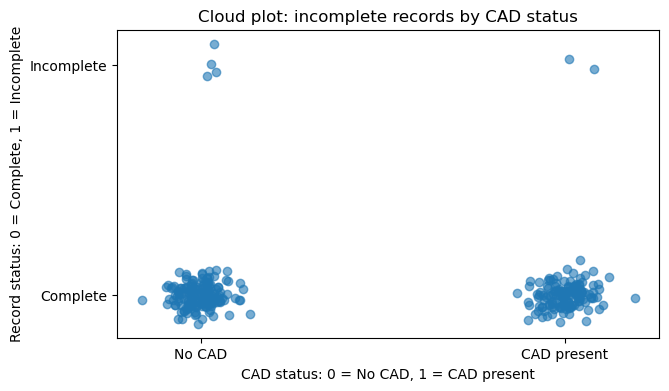

In [21]:
import numpy as np
import matplotlib.pyplot as plt

df_work["missing_row"] = df_work.isna().any(axis=1).astype(int)

np.random.seed(42)

x = df_work["target_binary"] + np.random.normal(0, 0.05, size=len(df_work))
y = df_work["missing_row"] + np.random.normal(0, 0.05, size=len(df_work))

plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.6)

plt.title("Cloud plot: incomplete records by CAD status")
plt.xlabel("CAD status: 0 = No CAD, 1 = CAD present")
plt.ylabel("Record status: 0 = Complete, 1 = Incomplete")

plt.xticks([0, 1], ["No CAD", "CAD present"])
plt.yticks([0, 1], ["Complete", "Incomplete"])

plt.show()

In [22]:
pd.crosstab(df_work["target_binary"], df_work["missing_row"])

missing_row,0,1
target_binary,,
0,160,4
1,137,2


In [23]:
df_complete = df_work.dropna().copy()

df_complete.shape

(297, 16)

In [24]:
df_complete["target_binary"].value_counts()

target_binary
0    160
1    137
Name: count, dtype: int64

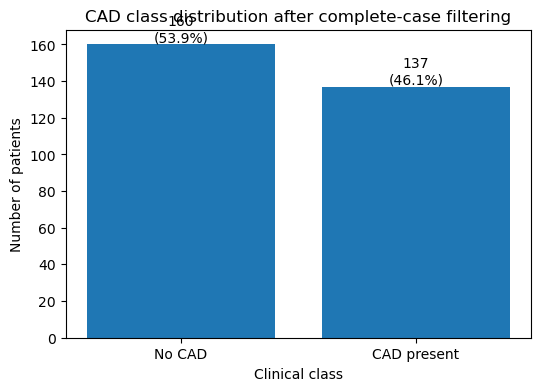

In [25]:
import matplotlib.pyplot as plt

class_counts = df_complete["target_binary"].value_counts().sort_index()
class_percent = df_complete["target_binary"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(["No CAD", "CAD present"], class_counts)

plt.title("CAD class distribution after complete-case filtering")
plt.xlabel("Clinical class")
plt.ylabel("Number of patients")

for bar, percent in zip(bars, class_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}\n({percent:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.show()

## 7. Statistical Analysis Plan

The notebook follows a staged clinical ML workflow:

1. Inspect missingness and define the complete-case analysis sample.
2. Summarize continuous variables using means, medians, quartiles, and visual distributions.
3. Use Shapiro-Wilk checks and skewness to justify nonparametric summaries.
4. Compare continuous variables by CAD status using Mann-Whitney U tests and rank-biserial effect sizes.
5. Compare categorical variables using chi-square/Fisher decision logic and Cramer's V.
6. Build a logistic regression benchmark with leakage-safe preprocessing.
7. Evaluate discrimination, threshold behavior, calibration, and clinical false-negative tradeoffs.
8. Validate internally using cross-validation and bootstrap confidence intervals.
9. Test clinical realism by removing `ca`.
10. Evaluate transportability using external UCI cohorts with shared predictors.

**Why this step matters:** A statistical plan clarifies which analyses are descriptive, which are predictive, and which are validation checks.

**Decision made:** Preserve the original nonparametric screening and logistic regression model-development strategy.

**Clinical interpretation:** Statistical screening supports clinical understanding; final model performance is judged using validation metrics.

**Limitation:** The notebook does not adjust exploratory p-values for multiple testing because screening is descriptive, not confirmatory.


## 8. Exploratory Data Analysis

This section describes the complete-case Cleveland cohort, examines continuous-variable distributions, and compares distributions between No CAD and CAD-present groups.

The EDA uses both numerical summaries and visual checks. Because several continuous variables are non-normal, robust summaries such as median, quartiles, and IQR are emphasized.

**Why this step matters:** EDA identifies distribution shape, outliers, class balance, and clinically plausible group differences before modeling.

**Decision made:** Keep all continuous predictors and inspect them without removing apparent outliers.

**Clinical interpretation:** Age, maximum heart rate, and exercise-related features show clinically meaningful separation between CAD groups.

**Limitation:** EDA is descriptive and does not establish causality.


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


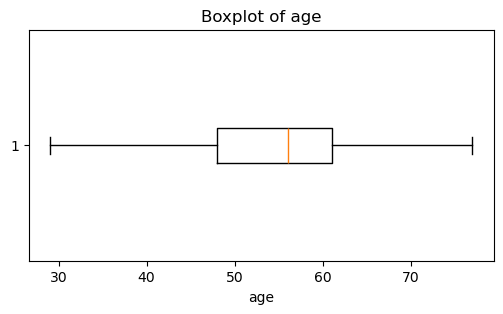

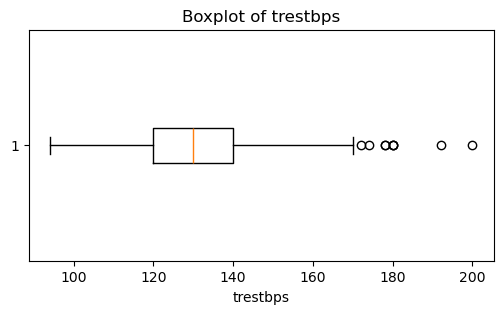

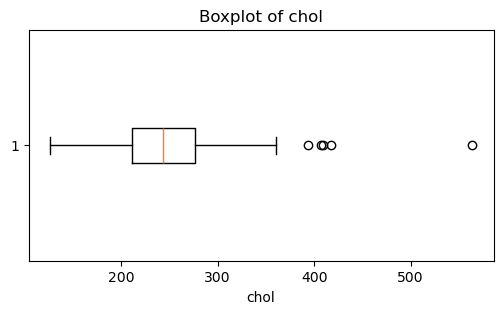

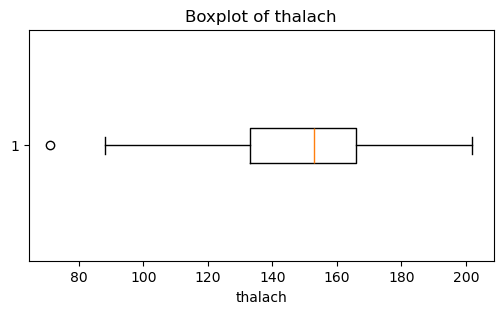

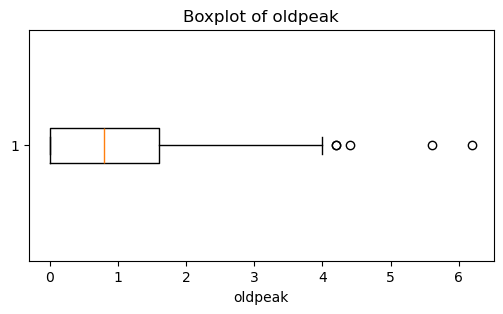

In [27]:
import matplotlib.pyplot as plt

continuous_vars = CONTINUOUS_VARS.copy()

# 1) Numerical summary
display(df_complete[continuous_vars].describe().T)

# 2) Visual outlier screening with boxplots
for var in continuous_vars:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df_complete[var], vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.show()



Variable: age
Shapiro-Wilk p-value: 0.0054
Skewness: -0.22
Interpretation: distribution is likely not normal.


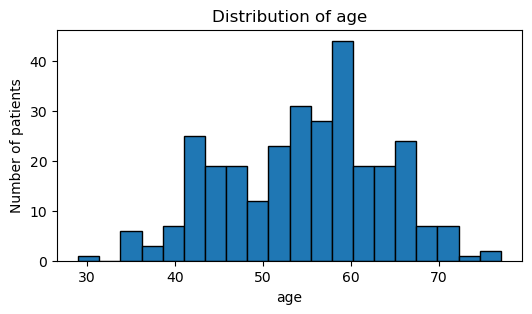


Variable: trestbps
Shapiro-Wilk p-value: 0.0000
Skewness: 0.70
Interpretation: distribution is likely not normal.


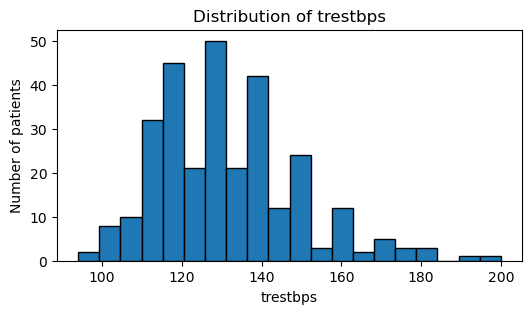


Variable: chol
Shapiro-Wilk p-value: 0.0000
Skewness: 1.11
Interpretation: distribution is likely not normal.


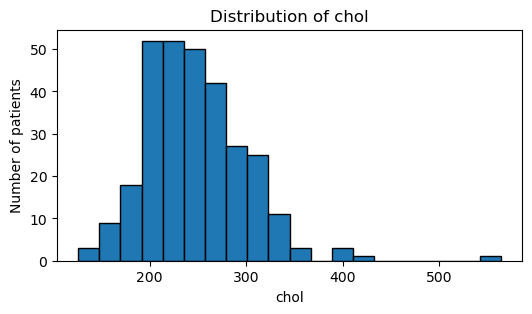


Variable: thalach
Shapiro-Wilk p-value: 0.0001
Skewness: -0.53
Interpretation: distribution is likely not normal.


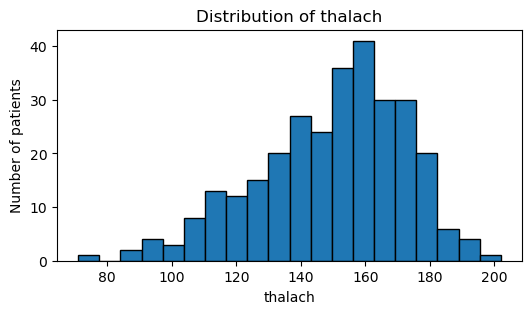


Variable: oldpeak
Shapiro-Wilk p-value: 0.0000
Skewness: 1.24
Interpretation: distribution is likely not normal.


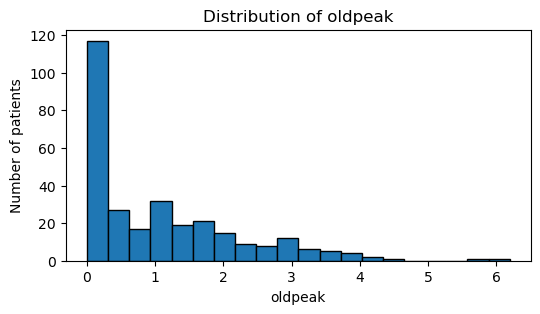

In [28]:
from scipy.stats import shapiro, skew
import matplotlib.pyplot as plt

continuous_vars = CONTINUOUS_VARS.copy()

for var in continuous_vars:
    values = df_complete[var].dropna()
    
    stat, p_value = shapiro(values)
    skewness = skew(values)
    
    print(f"\nVariable: {var}")
    print(f"Shapiro-Wilk p-value: {p_value:.4f}")
    print(f"Skewness: {skewness:.2f}")
    
    if p_value < 0.05:
        print("Interpretation: distribution is likely not normal.")
    else:
        print("Interpretation: no strong evidence against normality.")
    
    plt.figure(figsize=(6, 3))
    plt.hist(values, bins=20, edgecolor="black")
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Number of patients")
    plt.show()

,median,Q1,Q3,IQR
age,56.0,48.0,61.0,13.0
trestbps,130.0,120.0,140.0,20.0
chol,243.0,211.0,276.0,65.0
thalach,153.0,133.0,166.0,33.0
oldpeak,0.8,0.0,1.6,1.6


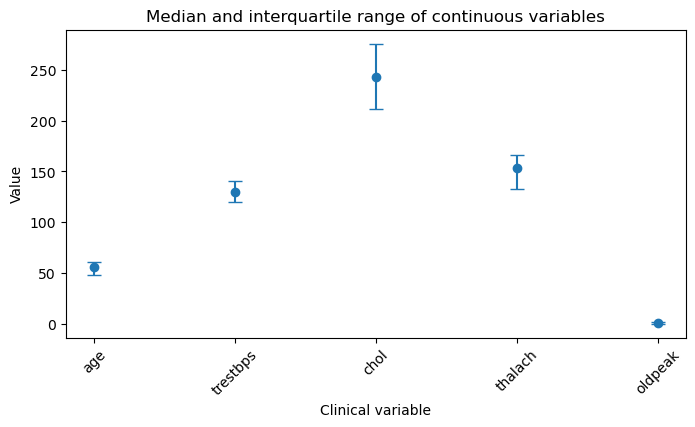

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

continuous_vars = CONTINUOUS_VARS.copy()

robust_summary = pd.DataFrame({
    "median": df_complete[continuous_vars].median(),
    "Q1": df_complete[continuous_vars].quantile(0.25),
    "Q3": df_complete[continuous_vars].quantile(0.75)
})

robust_summary["IQR"] = robust_summary["Q3"] - robust_summary["Q1"]

display(robust_summary)

plt.figure(figsize=(8, 4))

plt.errorbar(
    x=robust_summary.index,
    y=robust_summary["median"],
    yerr=[
        robust_summary["median"] - robust_summary["Q1"],
        robust_summary["Q3"] - robust_summary["median"]
    ],
    fmt="o",
    capsize=5
)

plt.title("Median and interquartile range of continuous variables")
plt.xlabel("Clinical variable")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

In [30]:
continuous_vars = CONTINUOUS_VARS.copy()

grouped_summary = (
    df_complete
    .groupby("target_binary")[continuous_vars]
    .agg(["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
)

grouped_summary

age                       trestbps                        \
              median <lambda_0> <lambda_1>   median <lambda_0> <lambda_1>   
target_binary                                                               
0               52.0      44.75       59.0    130.0      120.0      140.0   
1               58.0      53.00       62.0    130.0      120.0      145.0   

                chol                       thalach                        \
              median <lambda_0> <lambda_1>  median <lambda_0> <lambda_1>   
target_binary                                                              
0              235.5     208.75     268.25   161.0      149.0      172.0   
1              253.0     218.00     284.00   142.0      125.0      157.0   

              oldpeak                        
               median <lambda_0> <lambda_1>  
target_binary                                
0                 0.2        0.0        1.1  
1                 1.4        0.6        2.5

C:\Users\Gost\AppData\Local\Temp\ipykernel_29996\880630179.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


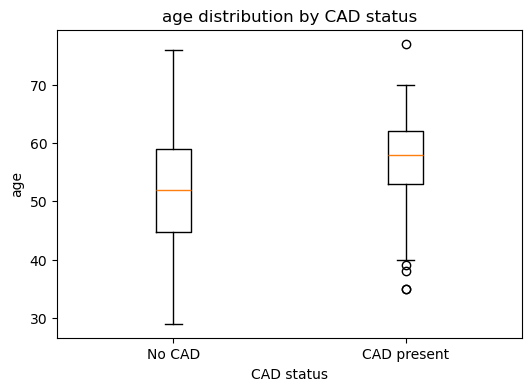

C:\Users\Gost\AppData\Local\Temp\ipykernel_29996\880630179.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


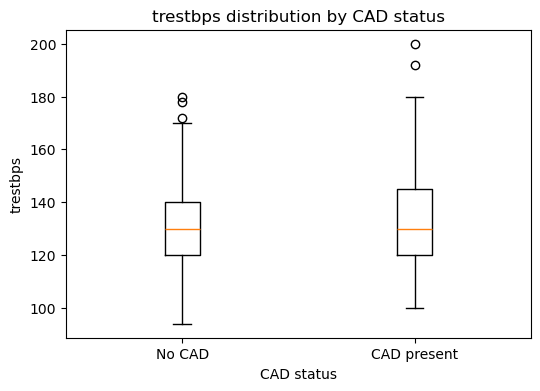

C:\Users\Gost\AppData\Local\Temp\ipykernel_29996\880630179.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


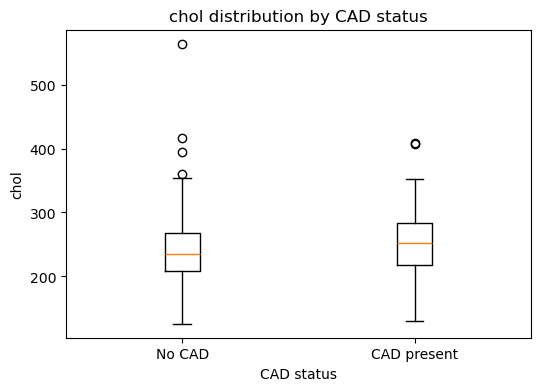

C:\Users\Gost\AppData\Local\Temp\ipykernel_29996\880630179.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


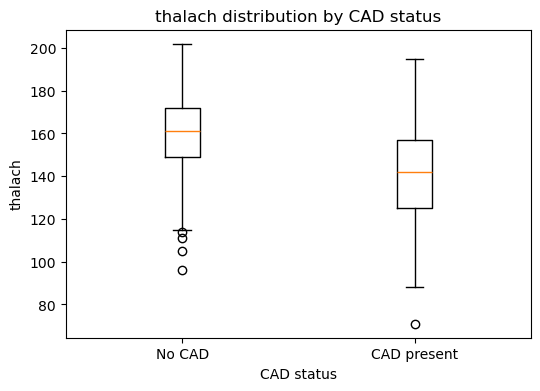

C:\Users\Gost\AppData\Local\Temp\ipykernel_29996\880630179.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


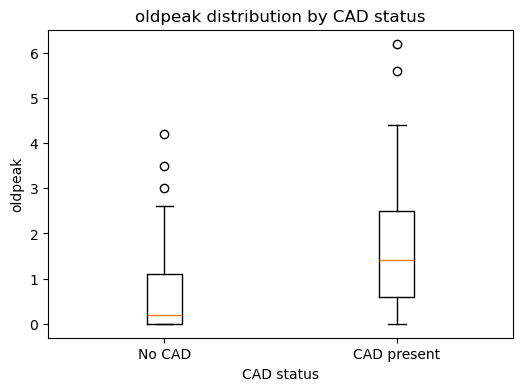

In [31]:
import matplotlib.pyplot as plt

continuous_vars = CONTINUOUS_VARS.copy()

for var in continuous_vars:
    no_cad = df_complete[df_complete["target_binary"] == 0][var]
    cad = df_complete[df_complete["target_binary"] == 1][var]
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(
        [no_cad, cad],
        labels=["No CAD", "CAD present"]
    )
    
    plt.title(f"{var} distribution by CAD status")
    plt.xlabel("CAD status")
    plt.ylabel(var)
    plt.show()

## 9. Statistical Screening

This section screens associations between candidate predictors and CAD status. Continuous predictors are assessed using Mann-Whitney U tests and rank-biserial correlation. Categorical predictors are assessed using chi-square/Fisher logic and Cramer's V.

The strongest categorical associations include `thal`, `cp`, `ca`, `exang`, and `slope`. Continuous variables such as `thalach` and `oldpeak` also show strong group separation.

**Why this step matters:** Screening helps reviewers see whether candidate predictors have clinically and statistically plausible relationships with CAD status.

**Decision made:** Use screening results for interpretation only; do not remove predictors solely based on univariate p-values.

**Clinical interpretation:** Several variables align with known clinical CAD signals, especially exercise response and diagnostic test features.

**Limitation:** Screening tests are univariate and do not account for confounding or predictor correlation.


In [32]:
from scipy.stats import mannwhitneyu

continuous_vars = CONTINUOUS_VARS.copy()

for var in continuous_vars:
    no_cad = df_complete[df_complete["target_binary"] == 0][var]
    cad = df_complete[df_complete["target_binary"] == 1][var]
    
    stat, p = mannwhitneyu(no_cad, cad, alternative="two-sided")
    
    print(f"{var}: U = {stat:.2f}, p-value = {p:.4f}")

age: U = 7916.50, p-value = 0.0000
trestbps: U = 9292.50, p-value = 0.0235
chol: U = 9492.00, p-value = 0.0467
thalach: U = 16399.00, p-value = 0.0000
oldpeak: U = 5833.50, p-value = 0.0000


In [33]:
import pandas as pd
from scipy.stats import mannwhitneyu

continuous_vars = CONTINUOUS_VARS.copy()

effect_results = []

for var in continuous_vars:
    no_cad = df_complete[df_complete["target_binary"] == 0][var]
    cad = df_complete[df_complete["target_binary"] == 1][var]
    
    n_no_cad = len(no_cad)
    n_cad = len(cad)
    
    # U for No CAD group
    u_stat, p_value = mannwhitneyu(no_cad, cad, alternative="two-sided")
    
    # Rank-biserial correlation
    rbc = (2 * u_stat) / (n_no_cad * n_cad) - 1
    
    effect_results.append({
        "variable": var,
        "U_statistic": u_stat,
        "p_value": p_value,
        "rank_biserial_correlation": rbc
    })

effect_results = pd.DataFrame(effect_results)

effect_results

,variable,U_statistic,p_value,rank_biserial_correlation
0,age,7916.5,3.672541e-05,-0.277692
1,trestbps,9292.5,2.345960e-02,-0.152144
2,chol,9492.0,4.668918e-02,-0.133942
3,thalach,16399.0,1.675290e-13,0.496259
4,oldpeak,5833.5,1.538610e-12,-0.467746


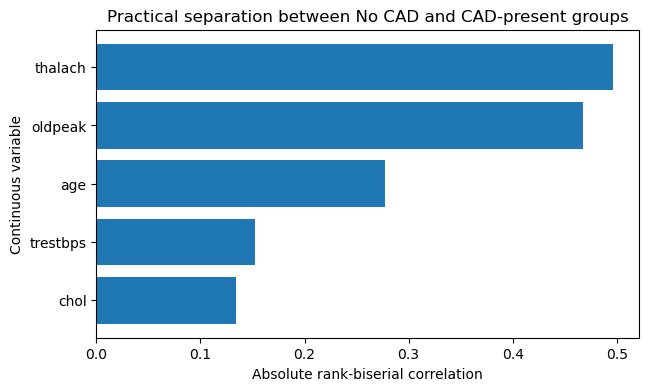

In [34]:
import matplotlib.pyplot as plt

effect_plot = effect_results.copy()
effect_plot["abs_effect"] = effect_plot["rank_biserial_correlation"].abs()
effect_plot = effect_plot.sort_values("abs_effect", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(effect_plot["variable"], effect_plot["abs_effect"])

plt.title("Practical separation between No CAD and CAD-present groups")
plt.xlabel("Absolute rank-biserial correlation")
plt.ylabel("Continuous variable")

plt.show()


===== sex =====


target_binary,0,1
sex,,
0.0,71,25
1.0,89,112


target_binary,0,1
sex,,
0.0,74.0,26.0
1.0,44.3,55.7


Expected counts:


target_binary,0,1
sex,,
0.0,51.72,44.28
1.0,108.28,92.72


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


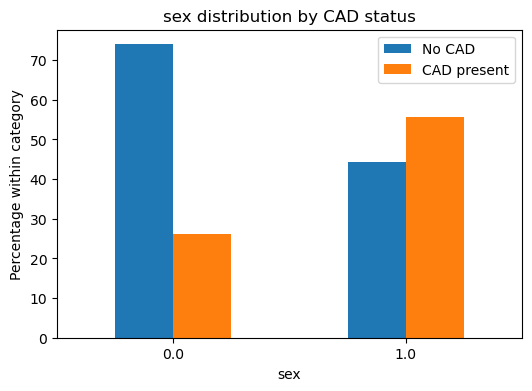


===== cp =====


target_binary,0,1
cp,,
1.0,16,7
2.0,40,9
3.0,65,18
4.0,39,103


target_binary,0,1
cp,,
1.0,69.6,30.4
2.0,81.6,18.4
3.0,78.3,21.7
4.0,27.5,72.5


Expected counts:


target_binary,0,1
cp,,
1.0,12.39,10.61
2.0,26.40,22.60
3.0,44.71,38.29
4.0,76.50,65.50


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


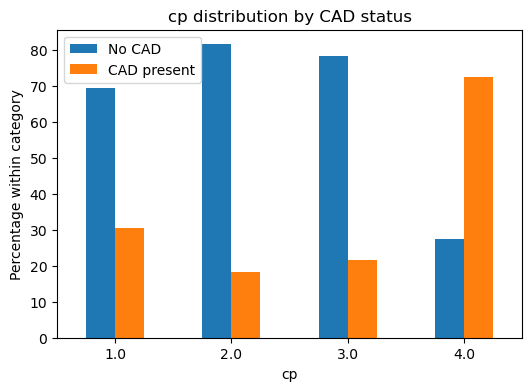


===== fbs =====


target_binary,0,1
fbs,,
0.0,137,117
1.0,23,20


target_binary,0,1
fbs,,
0.0,53.9,46.1
1.0,53.5,46.5


Expected counts:


target_binary,0,1
fbs,,
0.0,136.84,117.16
1.0,23.16,19.84


Test used: Chi-square
p-value: 1.0000
Chi-square assumptions acceptable.


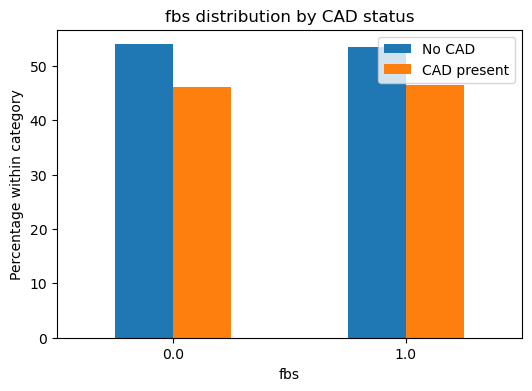


===== restecg =====


target_binary,0,1
restecg,,
0.0,92,55
1.0,1,3
2.0,67,79


target_binary,0,1
restecg,,
0.0,62.6,37.4
1.0,25.0,75.0
2.0,45.9,54.1


Expected counts:


target_binary,0,1
restecg,,
0.0,79.19,67.81
1.0,2.15,1.85
2.0,78.65,67.35


Test used: Chi-square
p-value: 0.0083


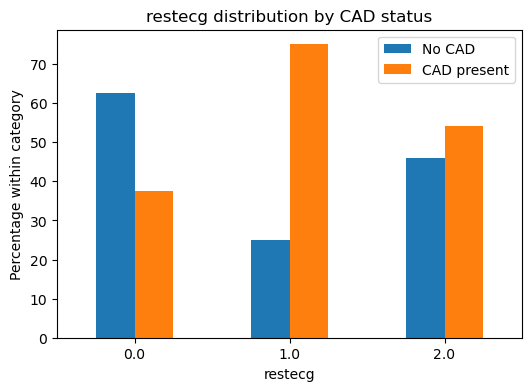


===== exang =====


target_binary,0,1
exang,,
0.0,137,63
1.0,23,74


target_binary,0,1
exang,,
0.0,68.5,31.5
1.0,23.7,76.3


Expected counts:


target_binary,0,1
exang,,
0.0,107.74,92.26
1.0,52.26,44.74


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


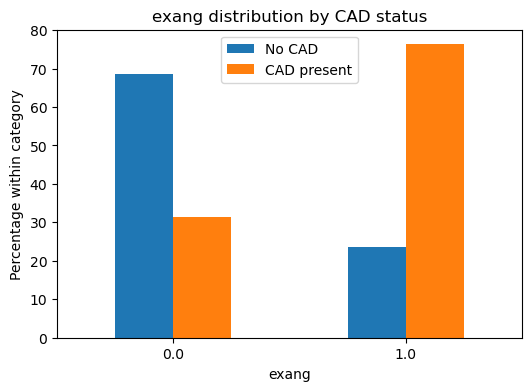


===== slope =====


target_binary,0,1
slope,,
1.0,103,36
2.0,48,89
3.0,9,12


target_binary,0,1
slope,,
1.0,74.1,25.9
2.0,35.0,65.0
3.0,42.9,57.1


Expected counts:


target_binary,0,1
slope,,
1.0,74.88,64.12
2.0,73.80,63.20
3.0,11.31,9.69


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


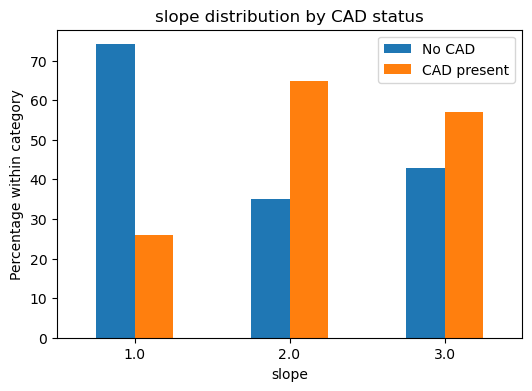


===== ca =====


target_binary,0,1
ca,,
0.0,129,45
1.0,21,44
2.0,7,31
3.0,3,17


target_binary,0,1
ca,,
0.0,74.1,25.9
1.0,32.3,67.7
2.0,18.4,81.6
3.0,15.0,85.0


Expected counts:


target_binary,0,1
ca,,
0.0,93.74,80.26
1.0,35.02,29.98
2.0,20.47,17.53
3.0,10.77,9.23


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


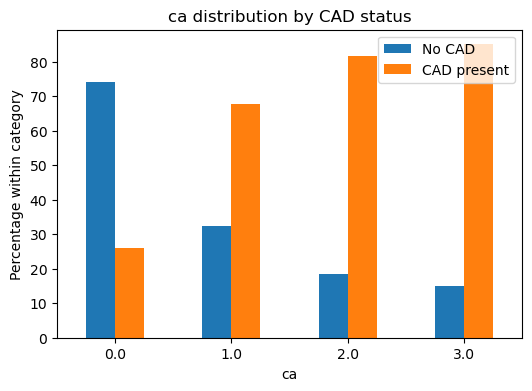


===== thal =====


target_binary,0,1
thal,,
3.0,127,37
6.0,6,12
7.0,27,88


target_binary,0,1
thal,,
3.0,77.4,22.6
6.0,33.3,66.7
7.0,23.5,76.5


Expected counts:


target_binary,0,1
thal,,
3.0,88.35,75.65
6.0,9.70,8.30
7.0,61.95,53.05


Test used: Chi-square
p-value: 0.0000
Chi-square assumptions acceptable.


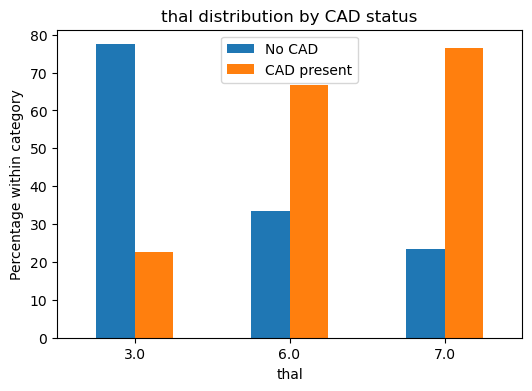

,variable,table_shape,test_used,p_value,small_expected_cells,percent_small_expected,note
7,thal,"(3, 2)",Chi-square,1.241673e-18,0,0.000000,Chi-square assumptions acceptable.
1,cp,"(4, 2)",Chi-square,1.178284e-16,0,0.000000,Chi-square assumptions acceptable.
6,ca,"(4, 2)",Chi-square,1.372578e-15,0,0.000000,Chi-square assumptions acceptable.
4,exang,"(2, 2)",Chi-square,9.510884e-13,0,0.000000,Chi-square assumptions acceptable.
5,slope,"(3, 2)",Chi-square,3.630107e-10,0,0.000000,Chi-square assumptions acceptable.
0,sex,"(2, 2)",Chi-square,2.945690e-06,0,0.000000,Chi-square assumptions acceptable.
3,restecg,"(3, 2)",Chi-square,8.331151e-03,2,33.333333,Warning: >20% of expected counts are <5; inter...
2,fbs,"(2, 2)",Chi-square,1.000000e+00,0,0.000000,Chi-square assumptions acceptable.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact

categorical_vars = CATEGORICAL_VARS.copy()

cat_results = []

for var in categorical_vars:
    print(f"\n===== {var} =====")
    
    # 1) Observed frequency table
    table = pd.crosstab(df_complete[var], df_complete["target_binary"])
    display(table)
    
    # 2) Row percentages
    row_percent = pd.crosstab(
        df_complete[var],
        df_complete["target_binary"],
        normalize="index"
    ) * 100
    
    display(row_percent.round(1))
    
    # 3) First run chi-square to calculate expected counts
    chi2, p_chi2, dof, expected = chi2_contingency(table)
    
    expected_df = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    )
    
    print("Expected counts:")
    display(expected_df.round(2))
    
    # 4) Check chi-square assumption
    small_expected_cells = (expected < 5).sum()
    total_cells = expected.size
    percent_small_expected = (small_expected_cells / total_cells) * 100
    
    # 5) Choose test
    if table.shape == (2, 2) and small_expected_cells > 0:
        oddsratio, p_value = fisher_exact(table)
        test_used = "Fisher exact"
        note = "Used Fisher because this is a 2x2 table with expected count(s) < 5."
    
    elif percent_small_expected > 20:
        p_value = p_chi2
        test_used = "Chi-square"
        note = "Warning: >20% of expected counts are <5; interpret chi-square cautiously."
    
    else:
        p_value = p_chi2
        test_used = "Chi-square"
        note = "Chi-square assumptions acceptable."
    
    print(f"Test used: {test_used}")
    print(f"p-value: {p_value:.4f}")
    print(note)
    
    cat_results.append({
        "variable": var,
        "table_shape": table.shape,
        "test_used": test_used,
        "p_value": p_value,
        "small_expected_cells": small_expected_cells,
        "percent_small_expected": percent_small_expected,
        "note": note
    })
    
    # 6) Plot
    row_percent.plot(kind="bar", figsize=(6, 4))
    plt.title(f"{var} distribution by CAD status")
    plt.xlabel(var)
    plt.ylabel("Percentage within category")
    plt.legend(["No CAD", "CAD present"])
    plt.xticks(rotation=0)
    plt.show()

cat_results = pd.DataFrame(cat_results).sort_values("p_value")
cat_results

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reuse the canonical Cleveland dataframe loaded at the top.
# This keeps the notebook restart-safe without a second data-loading path.
df_work = df.copy()
df_work["target_binary"] = (df_work["target"] > 0).astype(int)

df_complete = df_work.dropna().copy()

df_complete.shape


(297, 15)

,variable,cramers_v,p_value
0,thal,0.526919,1.241673e-18
1,cp,0.510086,1.178284e-16
2,ca,0.493392,1.372578e-15
3,exang,0.414154,9.510884e-13
4,slope,0.382589,3.630107e-10
5,sex,0.271246,2.945690e-06
6,restecg,0.179557,8.331151e-03
7,fbs,0.000000,1.000000e+00


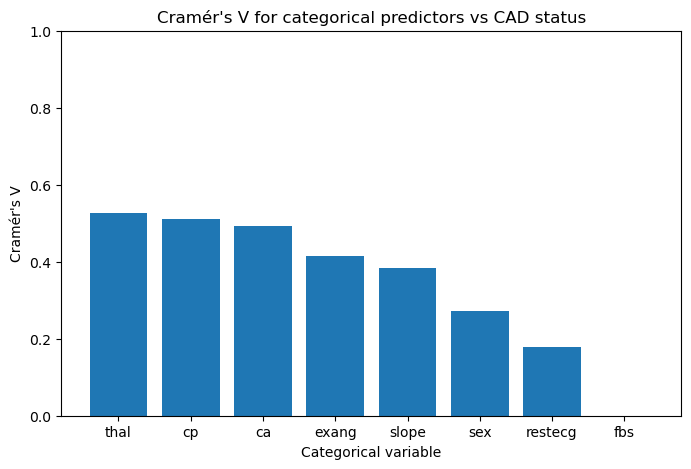

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

categorical_vars = CATEGORICAL_VARS.copy()

cramers_results = []

for var in categorical_vars:
    table = pd.crosstab(df_complete[var], df_complete["target_binary"])
    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    rows, cols = table.shape

    cramers_v = np.sqrt(chi2 / (n * (min(rows, cols) - 1)))

    cramers_results.append({
        "variable": var,
        "cramers_v": cramers_v,
        "p_value": p_value
    })

cramers_results = (
    pd.DataFrame(cramers_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

display(cramers_results)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(cramers_results["variable"], cramers_results["cramers_v"])
plt.title("Cram?r's V for categorical predictors vs CAD status")
plt.xlabel("Categorical variable")
plt.ylabel("Cram?r's V")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


## 10. Model Development

The benchmark model is logistic regression with a preprocessing pipeline. Continuous predictors are standardized, categorical predictors are one-hot encoded, and all preprocessing occurs inside the scikit-learn pipeline to avoid leakage.

The full benchmark model uses all 13 approved Cleveland predictors. Hyperparameter tuning uses 5-fold cross-validation and ROC-AUC scoring over a small grid of regularization strengths.

**Why this step matters:** Logistic regression is interpretable, probability-producing, and appropriate for a binary clinical prediction target.

**Decision made:** Preserve the original full-predictor logistic regression benchmark and tune only `C`.

**Clinical interpretation:** The model estimates `P(CAD present)` rather than producing a definitive diagnosis.

**Limitation:** Logistic regression assumes a relatively simple additive structure unless feature engineering or nonlinear terms are added.


In [39]:
continuous_vars = CONTINUOUS_VARS.copy()

categorical_vars = CATEGORICAL_VARS.copy()

target_var = "target_binary"

X = df_complete[continuous_vars + categorical_vars].copy()
y = df_complete[target_var].copy()

X.shape, y.shape


((297, 13), (297,))

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

((237, 13),
 (60, 13),
 target_binary
 0    0.540084
 1    0.459916
 Name: proportion, dtype: float64,
 target_binary
 0    0.533333
 1    0.466667
 Name: proportion, dtype: float64)

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_vars),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_vars)
    ]
)

preprocessor

ColumnTransformer(transformers=[('continuous', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

benchmark_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

benchmark_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=benchmark_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc"
)

grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_score_

({'model__C': 1}, np.float64(0.8997915417915416))

In [45]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

y_pred[:10], y_proba[:10]

(array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0]),
 array([0.02794976, 0.079578  , 0.50825103, 0.41487389, 0.34821956,
        0.01331939, 0.77535002, 0.06163242, 0.29122615, 0.08059752]))

In [46]:
pred_view = pd.DataFrame({
    "actual_y_test": y_test.values,
    "predicted_class": y_pred,
    "prob_No_CAD": best_model.predict_proba(X_test)[:, 0],
    "prob_CAD": best_model.predict_proba(X_test)[:, 1]
})

pred_view.head(15)

,actual_y_test,predicted_class,prob_No_CAD,prob_CAD
0,0,0,0.972050,0.027950
1,0,0,0.920422,0.079578
2,0,1,0.491749,0.508251
3,0,0,0.585126,0.414874
4,0,0,0.651780,0.348220
5,0,0,0.986681,0.013319
6,1,1,0.224650,0.775350
7,0,0,0.938368,0.061632
8,1,0,0.708774,0.291226
9,0,0,0.919402,0.080598


,Metric,Value
0,Accuracy,0.800
1,ROC-AUC,0.929


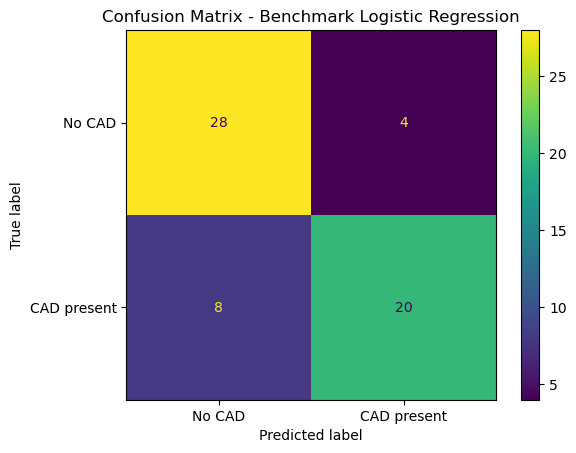

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Clean metric table
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [accuracy, roc_auc]
})

display(metrics_table.round(3))

# Visual confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No CAD", "CAD present"]
)

plt.title("Confusion Matrix - Benchmark Logistic Regression")
plt.show()


## 11. Threshold Analysis

The model produces probabilities, but clinical use requires a decision threshold. The notebook evaluates thresholds 0.30, 0.40, 0.50, and 0.60, with special attention to sensitivity and missed CAD cases.

At threshold 0.30, the benchmark model detects 26 of 28 CAD cases in the held-out test set and misses 2 CAD cases, at the cost of 6 false alarms.

**Why this step matters:** In CAD screening, false negatives may be more clinically concerning than false positives.

**Decision made:** Emphasize threshold 0.30 because it improves sensitivity compared with the default 0.50 threshold.

**Clinical interpretation:** Lowering the threshold increases CAD detection but also increases false alarms.

**Limitation:** The test set has only 60 patients, so threshold-specific counts are uncertain.


In [50]:
import pandas as pd
from sklearn.metrics import confusion_matrix

thresholds = THRESHOLDS.copy()

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    threshold_results.append({
        "threshold": t,
        "TP_detected_CAD": tp,
        "FN_missed_CAD": fn,
        "TN_correct_NoCAD": tn,
        "FP_false_alarm": fp,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "accuracy": (tp + tn) / (tp + tn + fp + fn)
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results.round(3))

,threshold,TP_detected_CAD,FN_missed_CAD,TN_correct_NoCAD,FP_false_alarm,sensitivity,specificity,accuracy
0,0.3,26,2,26,6,0.929,0.812,0.867
1,0.4,25,3,27,5,0.893,0.844,0.867
2,0.5,20,8,28,4,0.714,0.875,0.800
3,0.6,19,9,29,3,0.679,0.906,0.800


In [51]:
from sklearn.preprocessing import SplineTransformer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Linear benchmark = current model
linear_scores = cross_val_score(
    benchmark_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

# Nonlinear benchmark = splines for continuous variables
spline_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous_spline", SplineTransformer(n_knots=4, degree=3), continuous_vars),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_vars)
    ]
)

spline_model = Pipeline(
    steps=[
        ("preprocessor", spline_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

spline_scores = cross_val_score(
    spline_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

comparison = pd.DataFrame({
    "model": ["linear_logistic", "spline_logistic"],
    "mean_cv_auc": [linear_scores.mean(), spline_scores.mean()],
    "std_cv_auc": [linear_scores.std(), spline_scores.std()]
})

display(comparison.round(3))

,model,mean_cv_auc,std_cv_auc
0,linear_logistic,0.900,0.052
1,spline_logistic,0.902,0.056


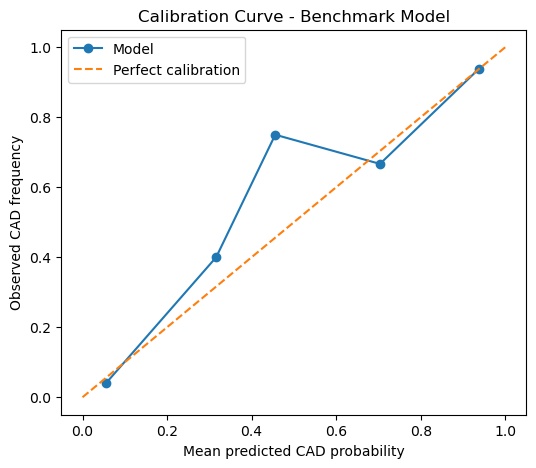

Brier score: 0.111


In [52]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_proba)

prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=5,
    strategy="uniform"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.title("Calibration Curve - Benchmark Model")
plt.xlabel("Mean predicted CAD probability")
plt.ylabel("Observed CAD frequency")
plt.legend()
plt.show()

print(f"Brier score: {brier:.3f}")

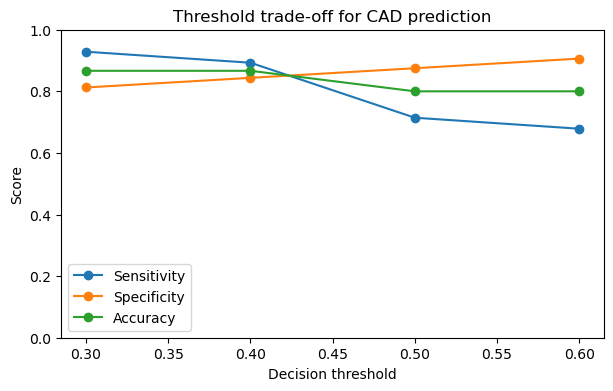

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(threshold_results["threshold"], threshold_results["sensitivity"], marker="o", label="Sensitivity")
plt.plot(threshold_results["threshold"], threshold_results["specificity"], marker="o", label="Specificity")
plt.plot(threshold_results["threshold"], threshold_results["accuracy"], marker="o", label="Accuracy")

plt.title("Threshold trade-off for CAD prediction")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

,feature,coefficient,abs_coefficient
16,categorical__ca_2.0,1.499632,1.499632
15,categorical__ca_1.0,1.490259,1.490259
19,categorical__thal_7.0,1.443068,1.443068
8,categorical__cp_4.0,1.431135,1.431135
5,categorical__sex_1.0,0.947915,0.947915
13,categorical__slope_2.0,0.751427,0.751427
4,continuous__oldpeak,0.592440,0.592440
7,categorical__cp_3.0,-0.580512,0.580512
17,categorical__ca_3.0,0.529975,0.529975
14,categorical__slope_3.0,0.429830,0.429830


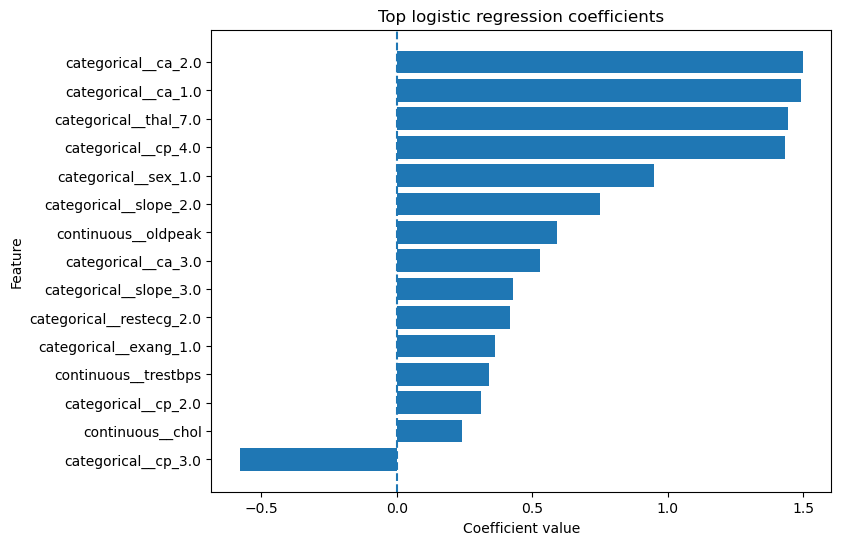

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get trained logistic regression model
log_reg = best_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg.coef_[0]
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)

display(coef_table.head(15))

# Plot top coefficients
top_coef = coef_table.head(15).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Top logistic regression coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

In [55]:
odds_table = coef_table.copy()

odds_table["odds_ratio"] = np.exp(odds_table["coefficient"])

odds_table = odds_table.sort_values("odds_ratio", ascending=False)

display(
    odds_table[["feature", "coefficient", "odds_ratio"]]
    .head(15)
    .round(3)
)

,feature,coefficient,odds_ratio
16,categorical__ca_2.0,1.500,4.480
15,categorical__ca_1.0,1.490,4.438
19,categorical__thal_7.0,1.443,4.234
8,categorical__cp_4.0,1.431,4.183
5,categorical__sex_1.0,0.948,2.580
13,categorical__slope_2.0,0.751,2.120
4,continuous__oldpeak,0.592,1.808
17,categorical__ca_3.0,0.530,1.699
14,categorical__slope_3.0,0.430,1.537
11,categorical__restecg_2.0,0.419,1.520


## 12. Internal Validation

Internal validation evaluates whether model performance is stable beyond a single split. The notebook uses cross-validation, model comparison, repeated stratified cross-validation, and bootstrap confidence intervals.

Random forest and gradient boosting do not improve meaningfully over logistic regression. Spline logistic regression has nearly the same cross-validated ROC-AUC as the linear logistic model, supporting the simpler benchmark.

**Why this step matters:** Clinical prediction models require validation beyond apparent training performance.

**Decision made:** Keep logistic regression as the main benchmark because more complex models did not materially improve performance.

**Clinical interpretation:** A simpler model with comparable performance is preferable for interpretability and communication.

**Limitation:** Internal validation cannot replace true prospective or external validation.


In [56]:
from sklearn.model_selection import cross_validate
import pandas as pd

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring=["roc_auc", "accuracy", "recall", "precision"],
    return_train_score=False
)

internal_validation = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Sensitivity/Recall", "Precision"],
    "mean_cv_score": [
        cv_results["test_roc_auc"].mean(),
        cv_results["test_accuracy"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_precision"].mean()
    ],
    "std_cv_score": [
        cv_results["test_roc_auc"].std(),
        cv_results["test_accuracy"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_precision"].std()
    ]
})

display(internal_validation.round(3))

,metric,mean_cv_score,std_cv_score
0,ROC-AUC,0.900,0.052
1,Accuracy,0.835,0.084
2,Sensitivity/Recall,0.797,0.138
3,Precision,0.836,0.091


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
import pandas as pd

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_cv = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring=["roc_auc", "accuracy", "recall", "precision"]
)

rf_validation = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Sensitivity/Recall", "Precision"],
    "mean_cv_score": [
        rf_cv["test_roc_auc"].mean(),
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_precision"].mean()
    ],
    "std_cv_score": [
        rf_cv["test_roc_auc"].std(),
        rf_cv["test_accuracy"].std(),
        rf_cv["test_recall"].std(),
        rf_cv["test_precision"].std()
    ]
})

display(rf_validation.round(3))

,metric,mean_cv_score,std_cv_score
0,ROC-AUC,0.890,0.052
1,Accuracy,0.801,0.081
2,Sensitivity/Recall,0.742,0.127
3,Precision,0.806,0.078


In [58]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
import pandas as pd

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ]
)

gb_cv = cross_validate(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring=["roc_auc", "accuracy", "recall", "precision"]
)

gb_validation = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Sensitivity/Recall", "Precision"],
    "mean_cv_score": [
        gb_cv["test_roc_auc"].mean(),
        gb_cv["test_accuracy"].mean(),
        gb_cv["test_recall"].mean(),
        gb_cv["test_precision"].mean()
    ],
    "std_cv_score": [
        gb_cv["test_roc_auc"].std(),
        gb_cv["test_accuracy"].std(),
        gb_cv["test_recall"].std(),
        gb_cv["test_precision"].std()
    ]
})

display(gb_validation.round(3))

,metric,mean_cv_score,std_cv_score
0,ROC-AUC,0.890,0.053
1,Accuracy,0.806,0.057
2,Sensitivity/Recall,0.788,0.122
3,Precision,0.788,0.042


In [59]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import pandas as pd
import warnings

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=KNOWN_ONEHOT_WARNING,
        category=UserWarning
    )
    logistic_repeated_cv = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring=["roc_auc", "accuracy", "recall", "precision"],
        return_train_score=False
    )

logistic_repeated_results = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Sensitivity/Recall", "Precision"],
    "mean_score": [
        logistic_repeated_cv["test_roc_auc"].mean(),
        logistic_repeated_cv["test_accuracy"].mean(),
        logistic_repeated_cv["test_recall"].mean(),
        logistic_repeated_cv["test_precision"].mean()
    ],
    "std_score": [
        logistic_repeated_cv["test_roc_auc"].std(),
        logistic_repeated_cv["test_accuracy"].std(),
        logistic_repeated_cv["test_recall"].std(),
        logistic_repeated_cv["test_precision"].std()
    ]
})

display(logistic_repeated_results.round(3))


,metric,mean_score,std_score
0,ROC-AUC,0.897,0.040
1,Accuracy,0.829,0.046
2,Sensitivity/Recall,0.790,0.089
3,Precision,0.836,0.067


,Metric,Value
0,Threshold,0.300
1,Accuracy,0.867
2,Sensitivity / Recall,0.929
3,Specificity,0.812
4,Precision,0.812
5,Missed CAD,2.000
6,False alarms,6.000


,precision,recall,f1-score,support
No CAD,0.929,0.812,0.867,32.000
CAD present,0.812,0.929,0.867,28.000
accuracy,0.867,0.867,0.867,0.867
macro avg,0.871,0.871,0.867,60.000
weighted avg,0.874,0.867,0.867,60.000


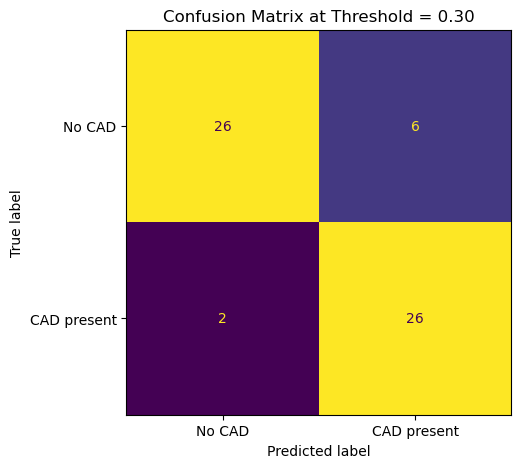

In [64]:
# Regenerate the threshold-0.30 evaluation with a clean visual output

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)

# 1) Choose threshold
threshold = THRESHOLDS[0]

# 2) Convert probabilities into class predictions
y_pred_03 = (y_proba >= threshold).astype(int)

# 3) Main metrics
acc = accuracy_score(y_test, y_pred_03)
sens = recall_score(y_test, y_pred_03)  # sensitivity = recall for CAD class
prec = precision_score(y_test, y_pred_03)

cm = confusion_matrix(y_test, y_pred_03)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)

# 4) Summary table
threshold_summary = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Sensitivity / Recall",
        "Specificity",
        "Precision",
        "Missed CAD",
        "False alarms"
    ],
    "Value": [
        threshold,
        acc,
        sens,
        spec,
        prec,
        fn,
        fp
    ]
})

display(threshold_summary.round(3))

# 5) Classification report as a table
report_dict = classification_report(
    y_test,
    y_pred_03,
    target_names=["No CAD", "CAD present"],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
display(report_df.round(3))

# 6) Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CAD", "CAD present"]
)
disp.plot(ax=ax, cmap="viridis", colorbar=False)
plt.title("Confusion Matrix at Threshold = 0.30")
plt.show()

## 13. Sensitivity Analysis Without `ca`

The predictor `ca` is clinically important but may be less realistic for early screening because it reflects fluoroscopy-derived vessel information. The notebook therefore compares the full model with a second logistic model that excludes `ca`.

Removing `ca` slightly weakens performance. In repeated CV, ROC-AUC drops from 0.897 to 0.875, and sensitivity/recall drops from 0.790 to 0.740. At threshold 0.30, the no-`ca` model misses 3 CAD cases rather than 2.

**Why this step matters:** A clinically realistic screening model should consider whether advanced diagnostic predictors are available at the intended decision point.

**Decision made:** Preserve both models and report the tradeoff rather than silently choosing one.

**Clinical interpretation:** `ca` improves performance, but excluding it may better approximate earlier-stage clinical use.

**Limitation:** This sensitivity analysis changes predictor availability but does not create a fully prospective screening protocol.


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import pandas as pd
import warnings

# Model B predictors: remove ca
categorical_vars_no_ca = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

X_no_ca = df_complete[continuous_vars + categorical_vars_no_ca].copy()
y_no_ca = df_complete["target_binary"].copy()

# Same train/test split logic
X_train_no_ca, X_test_no_ca, y_train_no_ca, y_test_no_ca = train_test_split(
    X_no_ca,
    y_no_ca,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_no_ca
)

# Preprocessor without ca
preprocessor_no_ca = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_vars),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_vars_no_ca)
    ]
)

# Logistic model without ca
model_no_ca = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_ca),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

# Repeated CV
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=KNOWN_ONEHOT_WARNING,
        category=UserWarning
    )
    no_ca_cv = cross_validate(
        model_no_ca,
        X_train_no_ca,
        y_train_no_ca,
        cv=repeated_cv,
        scoring=["roc_auc", "accuracy", "recall", "precision"],
        return_train_score=False
    )

no_ca_results = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Sensitivity/Recall", "Precision"],
    "Model A with ca": [
        logistic_repeated_cv["test_roc_auc"].mean(),
        logistic_repeated_cv["test_accuracy"].mean(),
        logistic_repeated_cv["test_recall"].mean(),
        logistic_repeated_cv["test_precision"].mean()
    ],
    "Model B without ca": [
        no_ca_cv["test_roc_auc"].mean(),
        no_ca_cv["test_accuracy"].mean(),
        no_ca_cv["test_recall"].mean(),
        no_ca_cv["test_precision"].mean()
    ]
})

no_ca_results["drop_without_ca"] = (
    no_ca_results["Model A with ca"] - no_ca_results["Model B without ca"]
)

display(no_ca_results.round(3))


,metric,Model A with ca,Model B without ca,drop_without_ca
0,ROC-AUC,0.897,0.875,0.022
1,Accuracy,0.829,0.792,0.037
2,Sensitivity/Recall,0.790,0.740,0.049
3,Precision,0.836,0.799,0.037


In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

# Fit Model B without ca
model_no_ca.fit(X_train_no_ca, y_train_no_ca)

# Probabilities
y_proba_A = y_proba  # Model A with ca, already created
y_proba_B = model_no_ca.predict_proba(X_test_no_ca)[:, 1]

thresholds = THRESHOLDS.copy()

comparison_rows = []

for model_name, probs, y_true in [
    ("Model A with ca", y_proba_A, y_test),
    ("Model B without ca", y_proba_B, y_test_no_ca)
]:
    for t in thresholds:
        y_pred_t = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        comparison_rows.append({
            "model": model_name,
            "threshold": t,
            "accuracy": accuracy_score(y_true, y_pred_t),
            "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp),
            "missed_CAD": fn,
            "false_alarms": fp
        })

threshold_model_comparison = pd.DataFrame(comparison_rows)

display(threshold_model_comparison.round(3))

,model,threshold,accuracy,sensitivity,specificity,missed_CAD,false_alarms
0,Model A with ca,0.3,0.867,0.929,0.812,2,6
1,Model A with ca,0.4,0.867,0.893,0.844,3,5
2,Model A with ca,0.5,0.800,0.714,0.875,8,4
3,Model A with ca,0.6,0.800,0.679,0.906,9,3
4,Model B without ca,0.3,0.850,0.893,0.812,3,6
5,Model B without ca,0.4,0.850,0.893,0.812,3,6
6,Model B without ca,0.5,0.833,0.786,0.875,6,4
7,Model B without ca,0.6,0.800,0.714,0.875,8,4


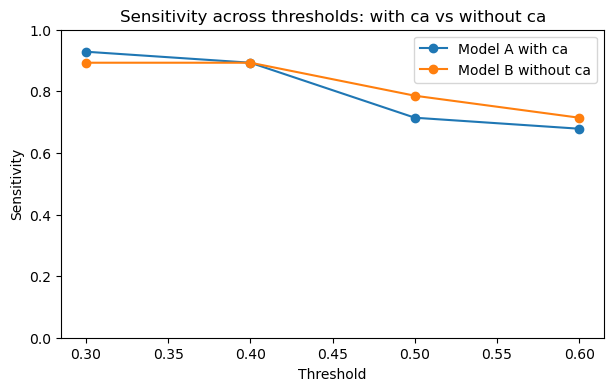

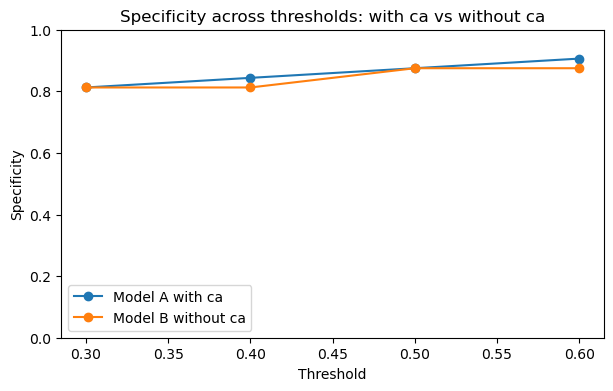

In [67]:
import matplotlib.pyplot as plt

# Plot sensitivity
plt.figure(figsize=(7, 4))

for model_name in threshold_model_comparison["model"].unique():
    data = threshold_model_comparison[
        threshold_model_comparison["model"] == model_name
    ]
    plt.plot(data["threshold"], data["sensitivity"], marker="o", label=model_name)

plt.title("Sensitivity across thresholds: with ca vs without ca")
plt.xlabel("Threshold")
plt.ylabel("Sensitivity")
plt.ylim(0, 1)
plt.legend()
plt.show()


# Plot specificity
plt.figure(figsize=(7, 4))

for model_name in threshold_model_comparison["model"].unique():
    data = threshold_model_comparison[
        threshold_model_comparison["model"] == model_name
    ]
    plt.plot(data["threshold"], data["specificity"], marker="o", label=model_name)

plt.title("Specificity across thresholds: with ca vs without ca")
plt.xlabel("Threshold")
plt.ylabel("Specificity")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [68]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score

# Bootstrap confidence intervals for Model A with ca
n_bootstrap = 1000
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_results = []

y_test_array = np.array(y_test)
y_proba_array = np.array(y_proba)

for i in range(n_bootstrap):
    sample_idx = rng.choice(len(y_test_array), size=len(y_test_array), replace=True)
    
    y_true_sample = y_test_array[sample_idx]
    y_proba_sample = y_proba_array[sample_idx]
    y_pred_sample = (y_proba_sample >= 0.30).astype(int)
    
    # Skip samples with only one class
    if len(np.unique(y_true_sample)) < 2:
        continue
    
    bootstrap_results.append({
        "ROC-AUC": roc_auc_score(y_true_sample, y_proba_sample),
        "Accuracy": accuracy_score(y_true_sample, y_pred_sample),
        "Sensitivity": recall_score(y_true_sample, y_pred_sample),
        "Precision": precision_score(y_true_sample, y_pred_sample, zero_division=0)
    })

bootstrap_df = pd.DataFrame(bootstrap_results)

ci_table = pd.DataFrame({
    "Metric": bootstrap_df.columns,
    "Mean": bootstrap_df.mean().values,
    "CI 2.5%": bootstrap_df.quantile(0.025).values,
    "CI 97.5%": bootstrap_df.quantile(0.975).values
})

display(ci_table.round(3))

,Metric,Mean,CI 2.5%,CI 97.5%
0,ROC-AUC,0.931,0.853,0.987
1,Accuracy,0.869,0.767,0.950
2,Sensitivity,0.930,0.815,1.000
3,Precision,0.814,0.667,0.944


In [71]:
from IPython.display import display

pd.set_option("display.max_colwidth", None)

final_summary = pd.DataFrame({
    "Model / Check": [
        "Logistic Regression with ca",
        "Logistic Regression without ca",
        "Random Forest",
        "Gradient Boosting",
        "Spline Logistic",
        "Clinical safety conclusion"
    ],
    "Main finding": [
        "Best benchmark model",
        "Slightly weaker but more clinically realistic",
        "Did not improve over logistic regression",
        "Did not improve over logistic regression",
        "No meaningful nonlinear improvement",
        "Model supports decisions but cannot replace clinicians"
    ],
    "Key result": [
        "Test ROC-AUC 0.929; threshold 0.30 sensitivity 0.929",
        "ROC-AUC drop about 0.022; threshold 0.30 missed 3 CAD",
        "CV ROC-AUC 0.890; sensitivity 0.742",
        "CV ROC-AUC 0.890; sensitivity 0.788",
        "CV ROC-AUC 0.902 vs linear 0.900",
        "False negatives still exist; clinical confirmation remains required"
    ]
})

display(final_summary)


,Model / Check,Main finding,Key result
0,Logistic Regression with ca,Best benchmark model,Test ROC-AUC 0.929; threshold 0.30 sensitivity 0.929
1,Logistic Regression without ca,Slightly weaker but more clinically realistic,ROC-AUC drop about 0.022; threshold 0.30 missed 3 CAD
2,Random Forest,Did not improve over logistic regression,CV ROC-AUC 0.890; sensitivity 0.742
3,Gradient Boosting,Did not improve over logistic regression,CV ROC-AUC 0.890; sensitivity 0.788
4,Spline Logistic,No meaningful nonlinear improvement,CV ROC-AUC 0.902 vs linear 0.900
5,Clinical safety conclusion,Model supports decisions but cannot replace clinicians,False negatives still exist; clinical confirmation remains required


## 14. External Validation

The external validation section tests transportability using other UCI heart disease cohorts. Because the full 13-predictor set is not complete in the external cohorts, the notebook builds a reduced Cleveland model using shared predictors: `age`, `sex`, `cp`, `restecg`, and `chol`.

The reduced model is trained on Cleveland and evaluated on Hungarian, Switzerland, and Long Beach VA cohorts. Results show partial transportability: ROC-AUC is 0.830 in Hungarian, 0.757 in Switzerland, and 0.672 in Long Beach VA.

**Why this step matters:** External validation is essential because clinical prediction models often lose performance in new populations.

**Decision made:** Use a reduced shared-predictor model for external validation rather than forcing the full model onto cohorts with severe missingness.

**Clinical interpretation:** The model generalizes moderately to some cohorts but performs weakly in Long Beach VA, especially for specificity.

**Limitation:** External validation results apply to the reduced model only, not the full 13-predictor benchmark.


In [73]:
import pandas as pd

columns = COLUMNS
dataset_urls = DATASET_URLS

datasets = {}

for name, url in dataset_urls.items():
    if name == "cleveland":
        temp = df.copy()
    else:
        temp = pd.read_csv(url, names=columns, na_values="?")
    temp["source"] = name
    datasets[name] = temp

quality_summary = []

for name, data in datasets.items():
    quality_summary.append({
        "dataset": name,
        "rows": data.shape[0],
        "columns": data.shape[1],
        "missing_values_total": data.isna().sum().sum(),
        "target_values": sorted(data["target"].dropna().unique())
    })

quality_summary = pd.DataFrame(quality_summary)
display(quality_summary)

missing_by_dataset = pd.DataFrame({
    name: data.isna().sum()
    for name, data in datasets.items()
})

display(missing_by_dataset)


,dataset,rows,columns,missing_values_total,target_values
0,cleveland,303,15,6,"[0, 1, 2, 3, 4]"
1,hungarian,294,15,782,"[0, 1]"
2,switzerland,123,15,273,"[0, 1, 2, 3, 4]"
3,long_beach_va,200,15,698,"[0, 1, 2, 3, 4]"


,cleveland,hungarian,switzerland,long_beach_va
age,0,0,0,0
sex,0,0,0,0
cp,0,0,0,0
trestbps,0,1,2,56
chol,0,23,0,7
fbs,0,8,75,7
restecg,0,1,1,0
thalach,0,1,1,53
exang,0,1,1,53
oldpeak,0,0,6,56


In [74]:
predictor_vars = continuous_vars + categorical_vars

complete_case_summary = []

for name, data in datasets.items():
    data_work = data.copy()
    data_work["target_binary"] = (data_work["target"] > 0).astype(int)
    
    complete_rows = data_work[predictor_vars + ["target_binary"]].dropna()
    
    complete_case_summary.append({
        "dataset": name,
        "total_rows": data_work.shape[0],
        "complete_rows_for_13_predictors": complete_rows.shape[0],
        "rows_lost": data_work.shape[0] - complete_rows.shape[0],
        "percent_complete": complete_rows.shape[0] / data_work.shape[0] * 100,
        "No_CAD": (complete_rows["target_binary"] == 0).sum(),
        "CAD_present": (complete_rows["target_binary"] == 1).sum()
    })

complete_case_summary = pd.DataFrame(complete_case_summary)

display(complete_case_summary.round(1))

,dataset,total_rows,complete_rows_for_13_predictors,rows_lost,percent_complete,No_CAD,CAD_present
0,cleveland,303,297,6,98.0,160,137
1,hungarian,294,1,293,0.3,0,1
2,switzerland,123,0,123,0.0,0,0
3,long_beach_va,200,1,199,0.5,0,1


dataset,cleveland,hungarian,long_beach_va,switzerland
variable,,,,
age,100.0,100.0,100.0,100.0
ca,98.7,1.0,1.0,4.1
chol,100.0,92.2,96.5,100.0
cp,100.0,100.0,100.0,100.0
exang,100.0,99.7,73.5,99.2
fbs,100.0,97.3,96.5,39.0
oldpeak,100.0,100.0,72.0,95.1
restecg,100.0,99.7,100.0,99.2
sex,100.0,100.0,100.0,100.0


dataset,cleveland,hungarian,long_beach_va,switzerland,min_external_availability
variable,,,,,
age,100.0,100.0,100.0,100.0,100.0
cp,100.0,100.0,100.0,100.0,100.0
sex,100.0,100.0,100.0,100.0,100.0
restecg,100.0,99.7,100.0,99.2,99.2
chol,100.0,92.2,96.5,100.0,92.2
thalach,100.0,99.7,73.5,99.2,73.5
exang,100.0,99.7,73.5,99.2,73.5
trestbps,100.0,99.7,72.0,98.4,72.0
oldpeak,100.0,100.0,72.0,95.1,72.0


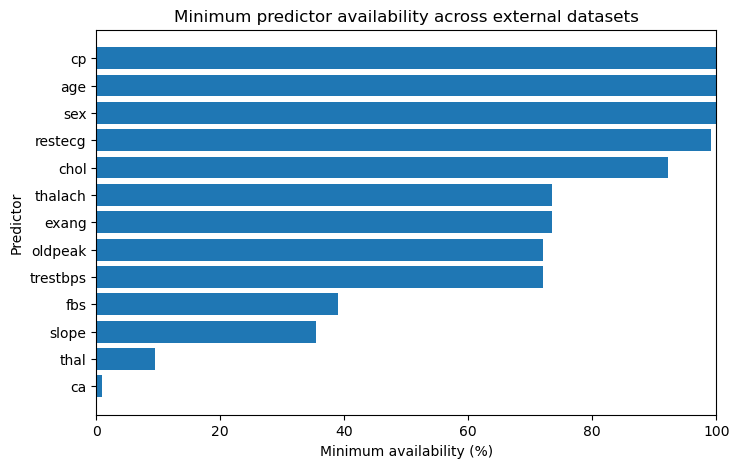

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

candidate_predictors = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

availability_rows = []

for name, data in datasets.items():
    for var in candidate_predictors:
        availability_rows.append({
            "dataset": name,
            "variable": var,
            "non_missing": data[var].notna().sum(),
            "total_rows": data.shape[0],
            "percent_available": data[var].notna().mean() * 100
        })

availability = pd.DataFrame(availability_rows)

availability_pivot = availability.pivot(
    index="variable",
    columns="dataset",
    values="percent_available"
)

display(availability_pivot.round(1))

# Minimum availability across all external datasets
availability_pivot["min_external_availability"] = availability_pivot[
    ["hungarian", "switzerland", "long_beach_va"]
].min(axis=1)

shared_predictor_candidates = availability_pivot.sort_values(
    "min_external_availability",
    ascending=False
)

display(shared_predictor_candidates.round(1))

# Plot
plot_data = shared_predictor_candidates["min_external_availability"].sort_values()

plt.figure(figsize=(8, 5))
plt.barh(plot_data.index, plot_data.values)
plt.title("Minimum predictor availability across external datasets")
plt.xlabel("Minimum availability (%)")
plt.ylabel("Predictor")
plt.xlim(0, 100)
plt.show()

In [76]:
shared_vars = SHARED_VARS.copy()
target_var = "target_binary"

# Cleveland reduced dataset
cleveland_reduced = datasets["cleveland"].copy()
cleveland_reduced["target_binary"] = (cleveland_reduced["target"] > 0).astype(int)
cleveland_reduced = cleveland_reduced[shared_vars + [target_var]].dropna()

# External reduced datasets
external_reduced = {}

for name in ["hungarian", "switzerland", "long_beach_va"]:
    temp = datasets[name].copy()
    temp["target_binary"] = (temp["target"] > 0).astype(int)
    temp = temp[shared_vars + [target_var]].dropna()
    external_reduced[name] = temp

# Summary
external_summary = pd.DataFrame({
    "dataset": ["cleveland", "hungarian", "switzerland", "long_beach_va"],
    "rows_available": [
        cleveland_reduced.shape[0],
        external_reduced["hungarian"].shape[0],
        external_reduced["switzerland"].shape[0],
        external_reduced["long_beach_va"].shape[0]
    ],
    "No_CAD": [
        (cleveland_reduced["target_binary"] == 0).sum(),
        (external_reduced["hungarian"]["target_binary"] == 0).sum(),
        (external_reduced["switzerland"]["target_binary"] == 0).sum(),
        (external_reduced["long_beach_va"]["target_binary"] == 0).sum()
    ],
    "CAD_present": [
        (cleveland_reduced["target_binary"] == 1).sum(),
        (external_reduced["hungarian"]["target_binary"] == 1).sum(),
        (external_reduced["switzerland"]["target_binary"] == 1).sum(),
        (external_reduced["long_beach_va"]["target_binary"] == 1).sum()
    ]
})

display(external_summary)

,dataset,rows_available,No_CAD,CAD_present
0,cleveland,303,164,139
1,hungarian,270,170,100
2,switzerland,122,8,114
3,long_beach_va,193,50,143


,external_dataset,n,ROC-AUC,Accuracy,Sensitivity,Specificity,Precision,Missed_CAD,False_alarms
0,hungarian,270,0.830,0.774,0.810,0.753,0.659,19,42
1,switzerland,122,0.757,0.803,0.816,0.625,0.969,21,3
2,long_beach_va,193,0.672,0.725,0.895,0.240,0.771,15,38


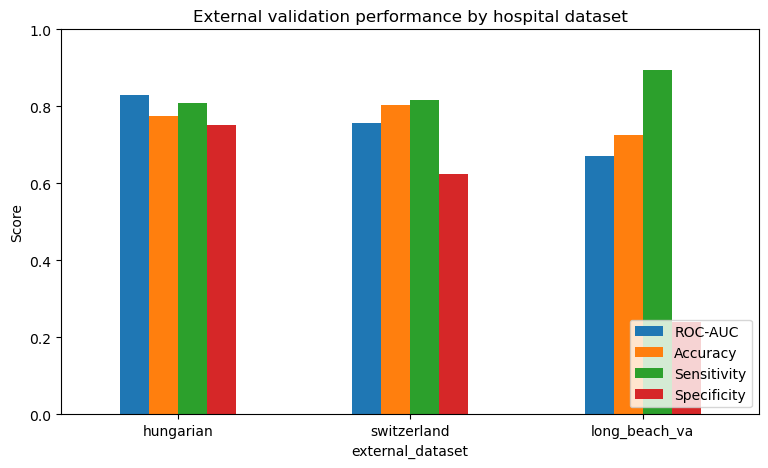

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

shared_vars = SHARED_VARS.copy()
shared_continuous = SHARED_CONTINUOUS.copy()
shared_categorical = SHARED_CATEGORICAL.copy()

X_clev = cleveland_reduced[shared_vars]
y_clev = cleveland_reduced["target_binary"]

shared_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), shared_continuous),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), shared_categorical)
    ]
)

external_model = Pipeline(
    steps=[
        ("preprocessor", shared_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

external_model.fit(X_clev, y_clev)

external_results = []

for name, data in external_reduced.items():
    X_ext = data[shared_vars]
    y_ext = data["target_binary"]
    
    y_ext_proba = external_model.predict_proba(X_ext)[:, 1]
    y_ext_pred = (y_ext_proba >= 0.30).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_ext, y_ext_pred).ravel()
    
    external_results.append({
        "external_dataset": name,
        "n": len(y_ext),
        "ROC-AUC": roc_auc_score(y_ext, y_ext_proba),
        "Accuracy": accuracy_score(y_ext, y_ext_pred),
        "Sensitivity": recall_score(y_ext, y_ext_pred),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_ext, y_ext_pred, zero_division=0),
        "Missed_CAD": fn,
        "False_alarms": fp
    })

external_results = pd.DataFrame(external_results)
display(external_results.round(3))

# Visual summary
plot_df = external_results.set_index("external_dataset")[["ROC-AUC", "Accuracy", "Sensitivity", "Specificity"]]

plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("External validation performance by hospital dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 15. Clinical Interpretation

The full Cleveland logistic regression model is the strongest benchmark within the primary dataset. It performs well on the held-out test set and maintains reasonable internal validation performance. The clinically preferred threshold in this notebook is 0.30 because it reduces missed CAD cases compared with the default 0.50 threshold.

The sensitivity analysis shows that `ca` contributes useful predictive information, but also raises a clinical realism question because it may not be available before advanced diagnostic workup. The external validation analysis shows that transportability is only partial when moving to other UCI cohorts.

**Why this step matters:** Clinical ML work must translate numerical performance into decision-relevant interpretation.

**Decision made:** Present the model as supportive risk estimation, not autonomous diagnosis.

**Clinical interpretation:** A low threshold may be appropriate when the priority is not missing possible CAD, but false alarms still require clinical follow-up capacity.

**Limitation:** No model in this notebook is validated enough for real clinical deployment.


## 16. Limitations

Key limitations of this case study:

- The Cleveland development dataset is small: 303 original patients and 297 complete cases.
- The held-out test set contains only 60 patients.
- The UCI datasets are historical and may not reflect current clinical practice.
- Complete-case analysis is transparent but may bias results if missingness is systematic.
- The original target is binarized, so disease severity information is not modeled.
- Predictor coding comes from the public dataset and is not fully re-curated from source clinical records.
- Some predictors, especially `ca` and `thal`, may represent advanced diagnostic information rather than initial screening information.
- External cohorts have severe missingness for the full predictor set.
- External validation required a reduced predictor set, so it does not validate the full 13-predictor benchmark.
- No prospective validation, recalibration study, decision-curve analysis, or clinical workflow evaluation is included.

**Why this step matters:** Limitations prevent overclaiming and define what would be required before real-world use.

**Decision made:** Keep conclusions proportional to the data and validation actually performed.

**Clinical interpretation:** The notebook is a strong portfolio case study, not a medical device evaluation.

**Limitation:** The available data do not support deployment claims.


## 17. Data and Code Availability

The data are loaded from the public UCI Machine Learning Repository processed heart disease files. The notebook stores dataset URLs in the reproducibility configuration cell.

This academic copy was created from `clinical-heart-disease-project.reproducible.ipynb`. The reproducibility notes are documented in `REPRODUCIBILITY_FIXES.md`, and the audit is documented in `clinical-heart-disease-project.audit.md`.

**Why this step matters:** Reviewers and clients should be able to trace the dataset source and understand how the notebook was made restart-safe.

**Decision made:** Preserve public URL-based loading and the reproducible notebook's configuration cell.

**Clinical interpretation:** Public data enable transparent demonstration, but public benchmark data are not equivalent to deployment data.

**Limitation:** Successful execution still depends on access to the UCI URLs or an equivalent local data mirror.


## 18. Final Conclusion

This notebook presents a complete clinical ML case study for CAD prediction using the UCI Heart Disease data. The strongest primary benchmark is a full-predictor logistic regression model trained on complete Cleveland cases. It achieves strong held-out discrimination and clinically useful sensitivity at a lower decision threshold, while remaining interpretable.

The analysis also shows why validation matters. More complex models do not materially improve performance, excluding `ca` creates a clinically meaningful performance tradeoff, and external validation on other UCI cohorts shows only partial transportability. These results support the model as an educational and portfolio-quality clinical prediction workflow, not as a standalone clinical diagnostic system.

**Why this step matters:** The conclusion ties together performance, clinical realism, and validation limits.

**Decision made:** Preserve the original scientific conclusions while presenting them in a clearer academic structure.

**Clinical interpretation:** The model may support risk stratification thinking, but final clinical decisions require physician evaluation and additional diagnostic evidence.

**Limitation:** Prospective validation and workflow-specific evaluation are required before any real clinical use.
